# LOO-PIT ANALYSIS of FLINCH

This notebook takes a Monte Carlo Markov Chain (MCMC) which was produced by FLINCH, a fully differentiable and high-performance framework for field-level inference on angular maps, and performs LOO-PIT (Leave One Out Cross Validation with Probability Integral Transform) analysis on the chain for model validation.

First, the project is activated in Julia with all necessary packages loaded

In [1]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()
Pkg.resolve()

  Activating project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts`
  No Changes to `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/Project.toml`
  No Changes to `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/Manifest.toml`


In [2]:
using Distributions
using LinearAlgebra
using StatsFuns
using StatsBase

using LogDensityProblems
using LogDensityProblemsAD
using AbstractDifferentiation
using MCMCDiagnosticTools
using AdvancedHMC
using MicroCanonicalHMC
using Pathfinder
using Transducers

using Healpix
using HealpixMPI
using MPI

using Plots
using StatsPlots
using LaTeXStrings
using DataFrames

using Random
using ProgressMeter
using BenchmarkTools
using NPZ
using CSV
using Test

using Zygote: @adjoint
using Zygote
using ChainRules.ChainRulesCore

include("AD_parallSHT.jl")
include("gen_datatest.jl")
include("reparam.jl")
include("utils.jl")
include("inference_model.jl")
include("neglogproblem.jl")

nℓπ_grad (generic function with 1 method)

In [3]:
# using Turing
# using Capse
using NPZ
# # using PlanckLite
# using BenchmarkTools
# using Plots
# using Optim
# using ForwardDiff
# using Pathfinder
# #using MicroCanonicalHMC
# #using Transducers
# using StatsPlots
# #using PairPlots
# #using LaTeXStrings
# #using CairoMakie
# using MCMCChains
using PSIS
# include("utils.jl");
using ArviZ
#using ArviZPythonPlots
using LinearAlgebra
using IrrationalConstants
using DimensionalData
using Statistics

In [4]:
Threads.nthreads()

4

An MCMC file is then read, representing the sampled parameters of the chain. Note that there is an option to read in and combine multiple files into a single data structure in order to represent a longer chain with more steps. It is important that if this option is utilized that all read files be of the same dimensionality (the same number of pixels sampled by the chain).

In [5]:
files = filter(
    f -> occursin("hsjv5", basename(f)) &&
         !occursin("_stats", basename(f)) &&
         !occursin("_SumPerf", basename(f)) &&
         !occursin("_EssRhat", basename(f)),
         
    readdir("/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/MPI_Chains/nside_16"; join=true)
)

# files = filter(
#     f -> occursin("nside_16", basename(f)) && 
#          occursin("_a.npy", basename(f)),
#     readdir("/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/MPI_Chains/nside_16"; join=true)
# )

for file in files
    println(file)
end

sort!(files)

sampled_params = hcat((npzread(f) for f in files)...)

# files = ["/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/MPI_Chains/nside_16/aNW8N_mask_NUTS_nside_16.npy"]
# sampled_params = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/MPI_Chains/nside_16/aNW8N_mask_NUTS_nside_16.npy")

samples = size(sampled_params, 2)

/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/MPI_Chains/nside_16/hsjv5_mask_NUTS_nside_16.npy


2000

In [6]:
ids = [
    replace(splitext(basename(f))[1],
            "_mask_NUTS_nside_16" => "")
    for f in files
]

runname = join(ids, "_")

"hsjv5"

The resolution parameters of the particular angular map used are set so as to be used in the analysis. This is set by the nside parameter. Once the resolution of the map is set one can create a realization map, a survey mask, and generated data measurements to compare against the sampled maps of the MCMC. 

The generated data measurements factor in noise as well as a Gaussian beam and pixel window function.

In [7]:
seed = 1123
Random.seed!(seed)

#   RESOLUTION PARAMETERS
nside = 16
lmax = 2*nside - 1

MPI.Init()

comm = MPI.COMM_WORLD
crank = MPI.Comm_rank(comm)
csize = MPI.Comm_size(comm)
root = 0
ncore = 32

#   REALIZATION MAP
realiz_Cl, realiz_HAlm, realiz_HMap = Realization("Capse_fiducial_Dl.csv", nside, lmax, seed)
realiz_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([realiz_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(realiz_Cl))

d = length(realiz_θ)

#   SURVEY MASK
mask_512 = readMapFromFITS("wmap_temperature_kq85_analysis_mask_r9_9yr_v5.fits",2,Float64)
mask_nside = udgrade(nest2ring(mask_512), nside)
for i in 1:length(mask_nside.pixels)
    if mask_nside.pixels[i]<=0.5
        mask_nside.pixels[i]=1
    else
        mask_nside.pixels[i]=0
    end
end

#   GENERATED DATA MEASUREMENTS
#   Noise
ϵ=150
N = ϵ*ones(nside2npix(nside))
N[mask_nside.==1] .= 5*10^4
#   Gaussian beam and pixel window function
Bl = ones(length(realiz_Cl))#gaussbeam(0.001, lmax, pol=false)
Pl = ones(length(realiz_Cl))#pixwin(nside, pol=false)[1:lmax+1]
BP_l = Bl.*Pl

#   Data Map
gen_Cl, gen_HAlm, gen_HMap = Measurement(realiz_Cl, Bl, Pl, mask_nside, N, nside, lmax, seed)
gen_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([gen_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(gen_Cl))
invN_HMap = HealpixMap{Float64,RingOrder}(1 ./ N)

#   STARTING POINT
start_Cl, start_HAlm, start_HMap = StartingPoint(gen_Cl, nside)
start_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([start_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(start_Cl))

#   PROMOTE HEALPIX.MAP TO HEALIPIXMPI.DMAP
gen_DMap = DMap{RR}(comm)
invN_DMap = DMap{RR}(comm)
HealpixMPI.Scatter!(gen_HMap, gen_DMap, comm, clear=true)
HealpixMPI.Scatter!(invN_HMap, invN_DMap, comm, clear=true)

helper_DMap = deepcopy(gen_DMap)

DMap: I am task 0 of 1, I work on 63 rings of 63
DMap: I am task 0 of 1, I work on 63 rings of 63


DMap{RR, Float64}([0.0; 0.0; … ; 106.75576281525872; 57.76576547614584;;], GeomInfoMPI(MPI.Comm(1140850688), 16, 64, [1.5707963267948966, 1.5291175943723188, 1.6124750592174744, 1.4873662401842815, 1.6542264134055116, 1.445468495626831, 1.696124157962962, 1.4033482475752073, 1.7382444060145859, 1.3609257345321588  …  0.25585245340993723, 2.885740200179856, 0.20448019896853478, 2.9371124546212584, 0.15324300949611616, 2.988349644093677, 0.10210642238260403, 3.039486231207189, 0.05103657515266638, 3.090556078437127], [32, 31, 33, 30, 34, 29, 35, 28, 36, 27  …  5, 59, 4, 60, 3, 61, 2, 62, 1, 63], [1, 65, 129, 193, 257, 321, 385, 449, 513, 577  …  2953, 2973, 2993, 3009, 3025, 3037, 3049, 3057, 3065, 3069], [64, 64, 64, 64, 64, 64, 64, 64, 64, 64  …  20, 20, 16, 16, 12, 12, 8, 8, 4, 4], [1.5707963267948966, 1.5291175943723188, 1.6124750592174744, 1.4873662401842815, 1.6542264134055116, 1.445468495626831, 1.696124157962962, 1.4033482475752073, 1.7382444060145859, 1.3609257345321588  …  0.25

One other very important note is the difference between a Healpix Map and a HealpixMPI Map (or a distributed Healpix Map where the pixels are distributed across multiple cores for faster processing). Both are data structures that represent angular sky maps by storing individual pixel values where the number of pixels in the map is set by the resolution nside parameter. 

However, Healpix and HealpixMPI store the pixels in different orders, according to either 'nested structure' or 'ringed structure'. Thus, one must be very careful when comparing maps that the maps are of the same type, and that the correct plotting functions are used such that the pixels are displayed properly in visual plots.

The cells below show the analysis flow for a single sample taken from the chain. Each step of the chain samples many parameters which are stored in the vector $\theta$. Most of the parameter vector is a series of $a_{lm}$ , the spherical harmonics of the angular map. These sampled $a_{lm}$ values are removed from the parameter vector and converted into a series of Healpix $a_{lm}$ and Healpix MPI $a_{lm}$.

In [8]:
θ = sampled_params[:,1500]
alm = θ[1:length(θ)-lmax-1]
sample_alm = x_vec2vecmat(alm, lmax, 1, comm, root=root)
sample_HAlm = from_alm_to_healpix_alm(sample_alm, lmax, 1)[1] # comm, root=root)[1]
sample_DAlm = HAlm2DAlm(sample_HAlm, comm; clear=true, root=root)

DAlm: I am task 0 of 1, I work on 32 m's of 31


DAlm{RR, ComplexF64}(ComplexF64[1.867897445682489e-5 + 0.0im; -1.5219032508720042e-6 + 0.0im; … ; 5.773655431357749 - 0.16788647676203267im; 0.18117017104630234 - 0.8904538353833993im;;], AlmInfoMPI(MPI.Comm(1140850688), 31, 31, 32, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9  …  22, 23, 24, 25, 26, 27, 28, 29, 30, 31], [1, 32, 62, 91, 119, 146, 172, 197, 221, 244  …  452, 461, 469, 476, 482, 487, 491, 494, 496, 497]))

The Healpix $a_{lm}$ values are then converted into a Healpix map that is plotted in order to visually see the latent sky map that is sampled in this step in the chain (sampled via the parameters $\theta$)

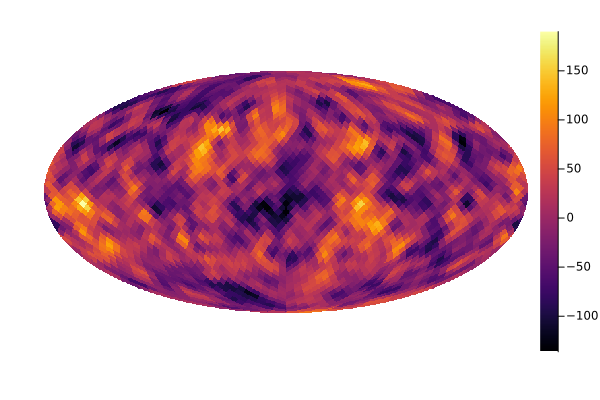

In [9]:
sample_HMap = Healpix.alm2map(sample_HAlm, nside)
plot(HealpixMap{Float64, RingOrder}(sample_HMap.pixels[:, 1]))

Now that we have explored the structure of the chain and how the parameters sampled in each step are related to a sampled sky map, we complete the analysis over the full chain.

Below, each step of the chain is extracted and converted from sampled parameter values $\theta$ to $a_{lm}$ values. These $a_{lm}$ values are used to store a Healpix map for each step. As well, for each pixel of the map, the Negative Log Likelihood (NLL) of that particular pixel is calculated and stored. For pixels that lie beneath the survey mask, the NLL is stored as NaN.

In [10]:
pixels = length(gen_DMap.pixels) 
NLLs = Matrix{Any}(undef, pixels, samples)
NLLs_HMap = [HealpixMap{Float64, RingOrder}(nside) for i in 1:samples]
samples_HMap = [HealpixMap{Float64, RingOrder}(nside) for i in 1:samples]

for n in 1:samples
    θ = sampled_params[:,n]
    alm = θ[1:length(θ)-lmax-1]
    sample_alm = x_vec2vecmat(alm, lmax, 1, comm, root=root)
    sample_HAlm = from_alm_to_healpix_alm(sample_alm, lmax, 1, comm, root=root)[1]
    sample_DAlm = HAlm2DAlm(sample_HAlm, comm; clear=true, root=root)
    
    Threads.@threads for i in 1:pixels
        NLL = NLL_Pixel(sample_DAlm, helper_DMap, ncore, gen_DMap, invN_DMap, BP_l, i)
        NLLs[i,n] = NLL
    end

    NLLs_pixels_n = map(x -> x === nothing ? NaN : x, NLLs[:, n])
    helper_DMap.pixels = reshape(NLLs_pixels_n, :, 1)
    MPI.Gather!(helper_DMap, NLLs_HMap[n])

    sample_HMap = Healpix.alm2map(sample_HAlm, nside)
    samples_HMap[n] = sample_HMap
end


DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am ta

In [11]:
NLLs_pixels = reduce(hcat, [NLLs_HMap[i].pixels for i in 1:samples])

3072×2000 Matrix{Float64}:
 0.564034     0.570947     0.579882     …  0.422448    0.431612    0.425347
 1.72445      1.71893      1.70922         3.0644      3.05977     3.05084
 0.0217272    0.0199914    0.0214314       0.0810883   0.0798334   0.0795489
 0.0318709    0.0336974    0.0342649       0.0755045   0.0740943   0.0756471
 0.0469453    0.0454963    0.0451441       0.0102491   0.00959979  0.0102146
 0.915017     0.895489     0.885037     …  0.999963    0.994312    0.995916
 0.0186394    0.0208048    0.0201574       0.0139607   0.014389    0.013228
 0.000320673  0.000268442  0.000277771     0.00616477  0.00626753  0.00593414
 0.528234     0.534099     0.527541        0.528275    0.526013    0.528326
 0.918804     0.930835     0.925536        1.56634     1.57457     1.57092
 0.859652     0.847687     0.841159     …  1.41153     1.40273     1.41333
 2.547        2.54799      2.58159         2.37747     2.38586     2.40073
 1.81788      1.82028      1.83588         1.95209     1.966

A sky map showing the Negative Log Likelihood values for each pixel is shown below for a single step of the chain. The structure NLLs_HMap is an array of length n where n is the length of the chain, and for each element it stores an array of NLL values for each pixel such that they can be plotted as below.

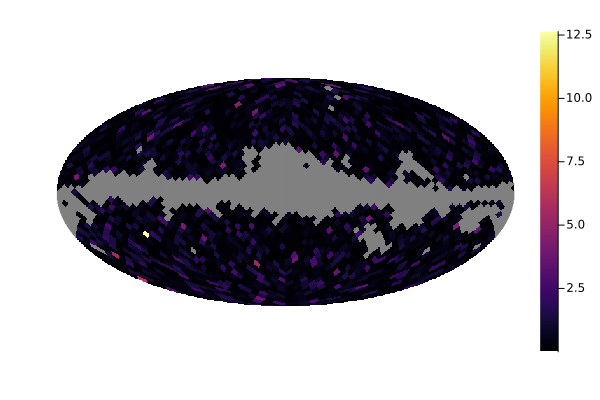

In [12]:
plot(NLLs_HMap[1000])

The next plot is a plot of the sampled latent sky map of the chain taken directly from the sampled parameters $\theta$ as shown above, chosen for a single step. The full data structure samples_HMap stores n sky maps where n is the length of the chain.

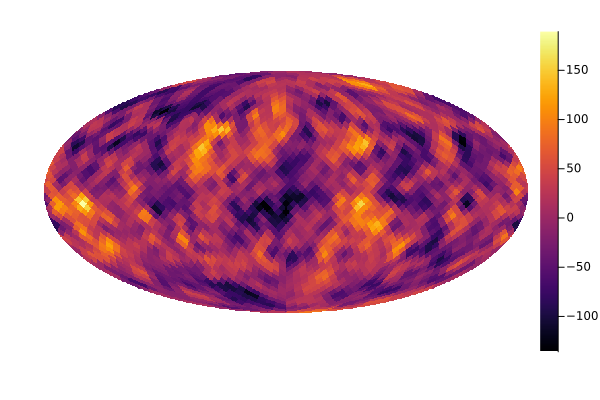

In [13]:
plot(samples_HMap[1000])

Now that the full chain has been read, and the sampled parameters have instead been turned into a series of sampled sky maps, the true analysis of LOO-PIT can begin.

The first step is to perform Pareto-Smoothed Importance Sampling (PSIS) on each pixel of the sky map. That is, we have a single array (coming from the chain) representing the full data. $P(y|\theta)$. However, for LOO-PIT we want to know $P(y_{i}|y_{-i},\theta)$. Rather than repeating the MCMC for each pixel (each time leaving out a different pixel) we perform PSIS to determine weights necessary to reweight the original chain.

In [14]:
psis_result = Vector{PSISResult{Float64, Vector{Float64}, Int64, Int64, PSIS.GeneralizedPareto{Float64}}}(undef, pixels);
for i in 1:pixels
    psis_result[i] = psis(NLLs_pixels[i,:])
end

┌ Warning: Tail contains non-finite values. Generalized Pareto distribution cannot be reliably fit.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:294
┌ Warning: Tail contains non-finite values. Generalized Pareto distribution cannot be reliably fit.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:294
┌ Warning: Tail contains non-finite values. Generalized Pareto distribution cannot be reliably fit.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:294
┌ Warning: Tail contains non-finite values. Generalized Pareto distribution cannot be reliably fit.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:294
┌ Warning: Tail contains non-finite values. Generalized Pareto distribution cannot be reliably fit.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:294
┌ Warning: Tail contains non-finite values. Generalized Pareto distribution cannot be reliably fit.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:294
┌ Warning: Tail contains non-finite values. Generalized Pareto distribution 

Performing PSIS gives a pareto shape value, k, for each pixel, which can be used as a diagnostic tool to infer how reliable the weighting is for that particular pixel.

Pareto Shapes: [0.06388931068526403, -0.14031983726477137, -0.15012288888357983, -0.36288653939420695, -0.7598706020000766, -0.4665511789665494, -0.48528467578584966, -0.42695220769392284, -0.4677647972715923, -0.41405082557094164, -0.28529844494720863, -0.5274321157724122, -0.4171002036554325, -0.2704489953898294, -0.4267728502702549, -0.15492193815222513, -0.4542921995780466, -0.5255846205873537, -0.5171673015266467, -0.4910096515874246, -0.37503864951222887, -0.7256602308684921, -0.388790288407062, -0.7732372681757483, -0.601766805254222, -0.22648134064326214, -0.392163590927086, -0.6067678131342957, -0.41015196189620773, -0.30281004005060824, -0.18345980619422972, -0.4533398338477036, -0.5055599620396023, -0.4255076050525585, -0.3280671947690599, -0.32859273610483075, -0.31127195799257373, -0.1247300527214284, -0.6310927938519918, 0.4759379647048167, -0.18338968524300514, -0.19058197189565024, -0.35209159562692305, -0.2856284155818833, -0.18723644098916575, -0.5926649179258531, -0.

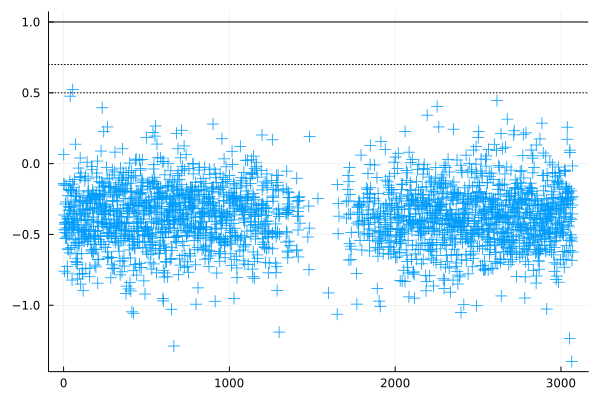

In [15]:
pareto_shapes = Vector{Float64}()
for i in 1:pixels
    append!(pareto_shapes, psis_result[i].pareto_shape)
end
println("Pareto Shapes: ", pareto_shapes)

shape_plot = Plots.scatter(pareto_shapes; marker =:+, markersize=6, legend = false, linewidth=2)
hline!([0.5,0.7], linestyle=:dot, color =:black)
hline!([1.0], linestyle=:solid, color=:black)

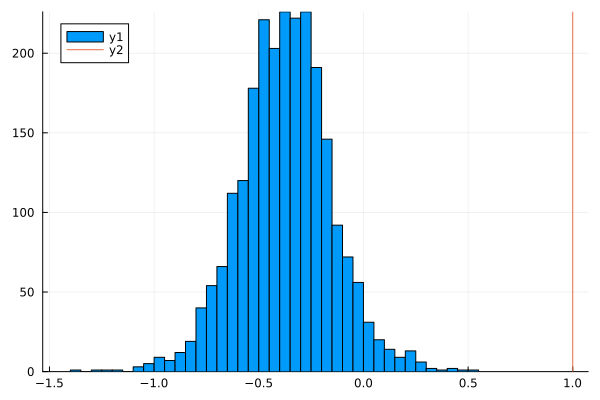

In [16]:
psis_shapes_hist = histogram(pareto_shapes)
vline!([1.0])

In [17]:
failure_count = 0                       #counts the number of pixels who have a pareto shape value exceeding the threshhold of 0.7
for i in 1:pixels
    if pareto_shapes[i] > 1.0
        global failure_count += 1
    end
end

unmasked_pixels = 0                     #counts the total number of pixels that are not covered by the survey mask
for i in 1:pixels
    if !isnan(pareto_shapes[i])
        global unmasked_pixels += 1
    end
end

failure_rate = failure_count / unmasked_pixels
println(failure_count)
println(failure_rate)

0
0.0


The results of PSIS, including the pareto shape parameters, and the failure rate (the number of pixels for which the pareto shape is >0.7 and thus PSIS is considered unreliable) are stored externally for observation and use. The plots above are also stored. As well, the Negative Log Likelihood values for each pixel at each step is stored externally.

In [18]:
mkpath("PSIS_results/$(samples)_$(nside)/$runname")
npzwrite("PSIS_results/$(samples)_$(nside)/$runname/pareto_shapes.npy", pareto_shapes)
npzwrite("PSIS_results/$(samples)_$(nside)/$runname/failure_rate.npy", [failure_count, unmasked_pixels, failure_rate])

mkpath("NLLs/$(samples)_$(nside)/$runname")
npzwrite("NLLs/$(samples)_$(nside)/$runname/NLLs.npy", NLLs_pixels)

Plots.savefig(shape_plot, "PSIS_results/$(samples)_$(nside)/$runname/pareto_shapes.png")
Plots.savefig(psis_shapes_hist, "PSIS_results/$(samples)_$(nside)/$runname/pareto_shapes_histogram.png")

"/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/PSIS_results/2000_16/hsjv5/pareto_shapes_histogram.png"

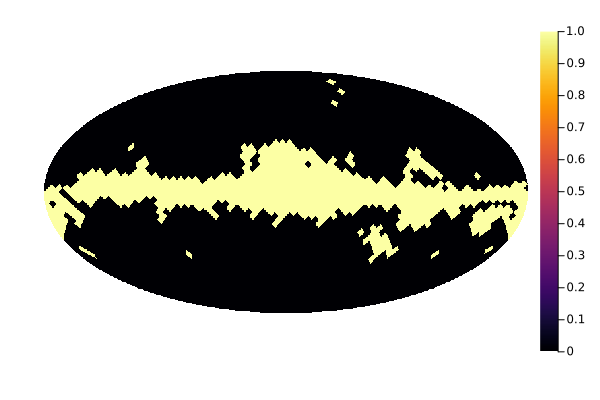

In [19]:
plot(mask_nside)

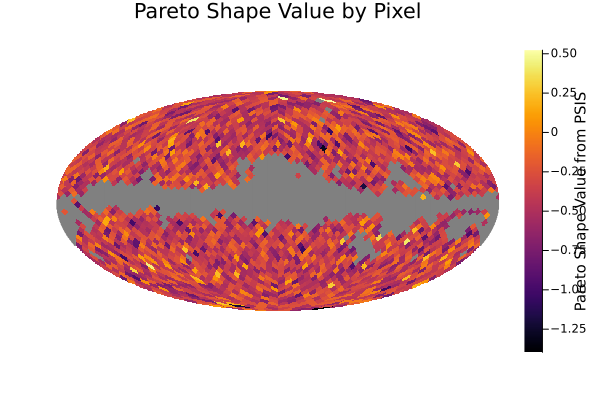

In [20]:
shape_mapping = HealpixMap{Float64, RingOrder, Vector{Float64}}(pareto_shapes)
shape_map = plot(shape_mapping, title="Pareto Shape Value by Pixel", colorbar_title="Pareto Shape Value from PSIS")

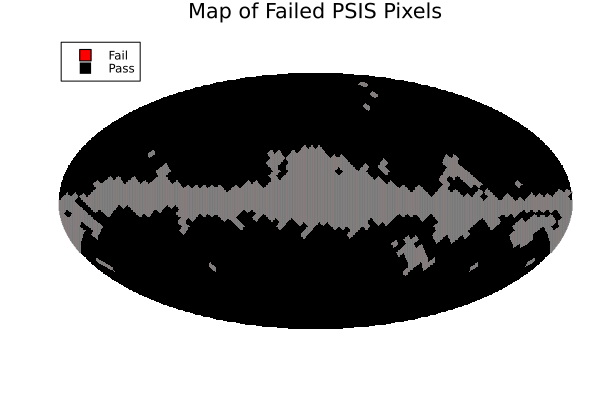

In [22]:
failure_vector = Vector{Float64}(undef, pixels)

for i in 1:pixels
    if isnan(pareto_shapes[i])
        failure_vector[i] = NaN
    elseif pareto_shapes[i] > 1.0
        failure_vector[i] = 1.0
    else
        failure_vector[i] = 0.0  
    end
end

failure_mapping = HealpixMap{Float64, RingOrder, Vector{Float64}}(failure_vector)
failure_map = plot(
    failure_mapping, 
    title = "Map of Failed PSIS Pixels", 
    colorbar = false,               
    c = [:black, :red],            
    clims = (0.0, 1.0)              
)
#inject fake series to give a legend
scatter!(failure_map, [NaN], [NaN], color=:red, label="Fail", markershape=:square)
scatter!(failure_map, [NaN], [NaN], color=:black, label="Pass", markershape=:square)

The plots above are plot of the pareto shape values used as diagnostics for PSIS, visualized on a pixel by pixel basis, and a binary plot showing which pixels specifically have exceeded the threshhold of 1.0, in order to see which pixels are unreliable for PSIS. Both plots are exported and saved externally for later checks and analysis. 

In [23]:
Plots.savefig(failure_map, "PSIS_results/$(samples)_$(nside)/$runname/failure_map.png")
Plots.savefig(shape_map, "PSIS_results/$(samples)_$(nside)/$runname/shape_map.png")

"/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/PSIS_results/2000_16/hsjv5/shape_map.png"

Finally, now that the PSIS has been completed and verified, it can be used to perform the LOO-PIT analysis on the chain. 

First, the generated data measurement (the "observed" data independent of the chain) is put into a data vector for comparison against the sampled sky maps. The mask is also defined in order to be applied to the sampled sky maps from the chain.

In [24]:
mask = .!isnan.(gen_HMap.pixels)
y_obs = gen_HMap.pixels;

The next step is to determine the sky maps that are sampled by the chain via the parameters. Above, in the field samples_HMap, we found the latent sky maps that are sampled by the parameters, but these latent sky maps are not what is actually observed. One needs to factor in the beam and pixel window and also noise on each pixel in order to have a true sampled sky map. 

This is done below. The process is very similar to above when the chain was processed, but now there is an extra step applying the beam and pixel window to the latent sky. The noise is added afterwards on a pixel by pixel basis.

In [25]:
#sampled_observed_maps = Vector{HealpixMap{Float64,RingOrder}}(undef, samples)
preds = Matrix{Float64}(undef, samples, pixels)

for s in 1:samples

    # Convert sampled parameters θ to Healpix alm
    θ = sampled_params[:,s]
    alm = θ[1:end-(lmax+1)]
    sample_alm = x_vec2vecmat(alm, lmax, 1, comm, root=root)
    sample_HAlm = from_alm_to_healpix_alm(sample_alm, lmax, 1, comm, root=root)[1]

    # Apply beam and pixel window
    pred_HAlm = almxfl(sample_HAlm, BP_l)

    # Convert to map
    sampled_observed_map = Healpix.alm2map(pred_HAlm, nside)


    # Independent observational noise
    noise = rand( MvNormal(zeros(length(N)), Diagonal(N)) )

    # Posterior predictive map
    pred_pixels = sampled_observed_map.pixels .+ noise

    # Keep observed pixels only
    preds[s,:] .= pred_pixels[mask]

end

Thus, the posterior predictive draws have been performed. The posterior sampling of the parameters has given a latent sky map which has then had the beam and pixel windows applied as well as noise, representing a draw from the posterior predictive. 

Finally, the posterior predictive draws are compared against the observed data realization of the sky map to determine the LOO-PIT value between 0 and 1.

In [26]:
loo_pit_values = Vector{Float64}(undef, pixels)

for j in 1:pixels

    # Retrieve PSIS log weights
    logw = copy(psis_result[j].log_weights)

    # Normalize the log weights
    logw .-= maximum(logw)

    w = exp.(logw)

    w ./= sum(w)

    # Weighted empirical CDF
    loo_pit_values[j] = sum(w .* (preds[:,j] .<= y_obs[j]))

end

Finally, the LOO-PIT values that were calculated above are plotted as a histogram for analysis. This plot is saved as an external file for viewing. 

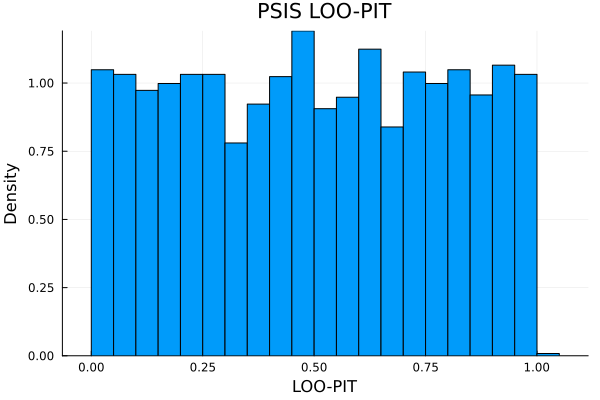

In [27]:
loo_pit_histogram = histogram(loo_pit_values, bins=20, normalize=:pdf, xlabel="LOO-PIT", ylabel="Density", title="PSIS LOO-PIT", legend = false)

In [28]:
mkpath("LOO-PIT_Plots/$(samples)_$(nside)/$runname")

Plots.savefig(loo_pit_histogram, "LOO-PIT_Plots/$(samples)_$(nside)/$runname/loo_pit_histogram.png")

"/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/LOO-PIT_Plots/2000_16/hsjv5/loo_pit_histogram.png"

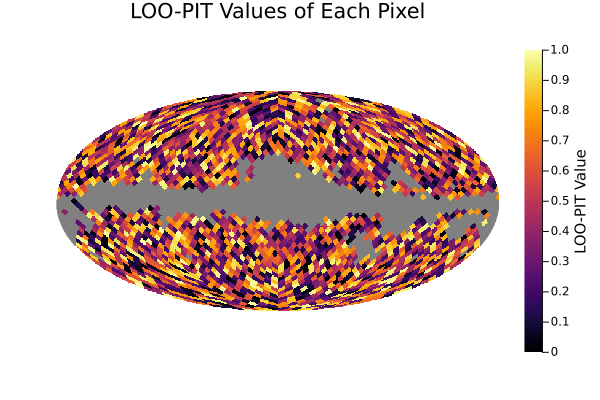

In [29]:
loo_pit_mapping = HealpixMap{Float64, RingOrder, Vector{Float64}}(loo_pit_values)
loo_pit_map = plot(loo_pit_mapping, title="LOO-PIT Values of Each Pixel", colorbar_title="LOO-PIT Value")

In [30]:
npzwrite("LOO-PIT_Plots/$(samples)_$(nside)/$runname/loo_pit_values.npy", loo_pit_values)
Plots.savefig(loo_pit_map, "LOO-PIT_Plots/$(samples)_$(nside)/$runname/loo_pit_map.png")

"/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/LOO-PIT_Plots/2000_16/hsjv5/loo_pit_map.png"